In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('41598_2024_61942_MOESM1_ESM.xlsx', sheet_name='Table_S7_Metadata_dysplasia', index_col=0)
df.head()

,Group_HC_dysplasia,Group_HC_LSIL_HSIL,Group_CIN,Age_atSampling,Menses_yesno,WeeksLastMenses,Gyn_problem_24hrs,Gyn_Intermittentbleeding,Gyn_Smell,Gyn_Itch,...,Gyn_BloodyDischarge,Gyn_Otherproblem24hrs,Intercourse24hrs,AB3months_sampling,HPV16,HPV16_HPV18_HPV45,HighRisk_HPV_type,PotentialHR_HPV,LowRisk_HPV,Group_HighRisk_LowRisk_NEG_HPV
SampleID,,,,,,,,,,,,,,,,,,,,,
Dysp_0001,dysplasia,HSIL/cancer,cancer in situ,24,menses,three weeks,No trouble,No,No,No,...,No,No,No,No,1,YES_161845,YES_HR,0,1,HR_potHR
Dysp_0002,dysplasia,HSIL/cancer,cancer in situ,52,menses,one week,No trouble,No,No,No,...,No,No,No,No,0,NO_161845,YES_HR,0,0,HR_potHR
Dysp_0003,dysplasia,HSIL/cancer,cancer in situ,50,nomenses,no menses,No trouble,No,No,No,...,No,No,No,No,1,YES_161845,YES_HR,0,0,HR_potHR
Dysp_0004,dysplasia,HSIL/cancer,moderate,25,NaN,NaN,No trouble,No,No,No,...,No,No,NaN,NaN,0,NO_161845,NO_HR,0,0,neg
Dysp_0005,dysplasia,LSIL,not applicable,31,menses,one week,No trouble,No,No,No,...,No,No,No,No,0,NO_161845,YES_HR,0,0,HR_potHR


In [3]:
df.shape

(354, 22)

### Add read counts (after preprocessing)

In [4]:
read_counts = pd.read_csv('read_counts_post_qc.csv', index_col=0)
read_counts.head()

,num_reads
sample,
Dysp_0001,9958706
Dysp_0002,7329914
Dysp_0003,1136536
Dysp_0004,8973572
Dysp_0005,14572788


In [5]:
df['num_reads'] = df.index.map(read_counts['num_reads'])

In [6]:
df['num_reads'].min(), df['num_reads'].max()

(0.0, 108064394.0)

In [7]:
df[df['num_reads'] >250000].shape, df.shape

((352, 23), (354, 23))

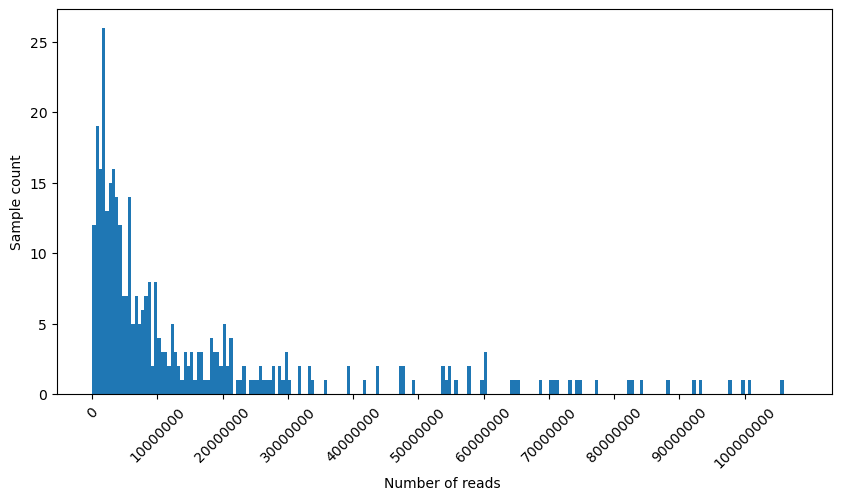

In [8]:
plt.figure(figsize=(10,5))
plt.hist(df['num_reads'], bins = np.arange(0,108064394, 500000 ))
plt.xlabel('Number of reads ')

plt.ylabel('Sample count')

plt.xticks(np.arange(0,108064394, 10000000 ), rotation=45)
plt.ticklabel_format(style='plain') 
plt.show()

In [9]:
df.value_counts('Group_HC_dysplasia')

Group_HC_dysplasia
HC           177
dysplasia    177
Name: count, dtype: int64

In [10]:
df.value_counts('Group_HC_LSIL_HSIL')

Group_HC_LSIL_HSIL
Healthy controls    177
HSIL/cancer          96
LSIL                 81
Name: count, dtype: int64

In [11]:
df.value_counts('HPV16_HPV18_HPV45')

HPV16_HPV18_HPV45
NO_161845     303
YES_161845     51
Name: count, dtype: int64

In [12]:
df.value_counts('HPV16')

HPV16
0    315
1     39
Name: count, dtype: int64

### Make variables binary integers when possible

In [13]:
def yes_no_to_binary(val):

    if pd.isna(val) or val == 'no menses' or val == 'not applicable':
        return np.nan
    elif isinstance(val, str) and 'yes' in val.lower() or val=='menses':
        return 1
    elif isinstance(val, str) and 'no' in val.lower():
        return 0
    else:
        return val  # Optional: keep other values unchanged

In [14]:
df_binary = df.applymap(yes_no_to_binary)
df_binary['outcome'] = df['Group_HC_dysplasia'].map({'HC': 0, 'dysplasia': 1})
df_binary['WeeksLastMenses'] = df['WeeksLastMenses'].map({'no menses': np.nan, 
                                                          'one week': 1,
                                                          'two weeks': 2,
                                                          'three weeks': 3,
                                                          'four weeks': 4,
                                                         })


/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_6955/1679340779.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_binary = df.applymap(yes_no_to_binary)


In [15]:
for i in df.columns:
    if i == 'Age_atSampling' or i == 'num_reads':
        continue
    print(i)
    print(df[i].value_counts(dropna=False))
    print(df_binary[i].value_counts(dropna=False))
    print()
        

Group_HC_dysplasia
Group_HC_dysplasia
dysplasia    177
HC           177
Name: count, dtype: int64
Group_HC_dysplasia
dysplasia    177
HC           177
Name: count, dtype: int64

Group_HC_LSIL_HSIL
Group_HC_LSIL_HSIL
Healthy controls    177
HSIL/cancer          96
LSIL                 81
Name: count, dtype: int64
Group_HC_LSIL_HSIL
Healthy controls    177
HSIL/cancer          96
LSIL                 81
Name: count, dtype: int64

Group_CIN
Group_CIN
not applicable    286
cancer in situ     45
moderate           23
Name: count, dtype: int64
Group_CIN
NaN               286
cancer in situ     45
moderate           23
Name: count, dtype: int64

Menses_yesno
Menses_yesno
menses      221
nomenses    109
NaN          24
Name: count, dtype: int64
Menses_yesno
1.0    221
0.0    109
NaN     24
Name: count, dtype: int64

WeeksLastMenses
WeeksLastMenses
no menses      109
two weeks       67
three weeks     56
one week        55
four weeks      43
NaN             24
Name: count, dtype: int64
WeeksLas

In [16]:
df_binary.to_csv('metadata.csv')